🚀 [步驟二] 混合特徵訓練 (BERT + TF-IDF + SMOTE)
✅ 資料載入完成: 47275 筆
🤖 載入 BERT 模型 (bert-base-chinese)...
   -> 硬體加速: mps
🔄 提取 BERT 向量 (共 47275 筆)...
   -> 進度: 44800/47275
🔄 提取 TF-IDF 特徵...
📖 計算情緒字典特徵...
🔗 合併所有特徵...
   -> 最終特徵維度: (47275, 5772)
✂️ 10-Fold 切分 & SMOTE 平衡...
⚖️ 執行 SMOTE 過取樣 (生成新樣本)...
   -> 訓練集擴增: 42547 -> 146304
🏋️ 訓練模型 (Logistic Regression + SGD)...


Exception ignored in: <function ResourceTracker.__del__ at 0x106f2a020>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x112112020>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10527a020>
Traceback (most recent call last

✅ 訓練完成！
📊 產生評估報告...

🏆 Accuracy: 0.6662
🏆 F1-Score: 0.6686

Classification Report:
                  precision    recall  f1-score   support

      feel_angry       0.63      0.69      0.66       635
     feel_boring       0.50      0.71      0.59       285
 feel_depressing       0.67      0.85      0.75       320
      feel_happy       0.62      0.61      0.61       978
feel_informative       0.82      0.61      0.70      1979
        feel_odd       0.51      0.78      0.62       295
       feel_warm       0.62      0.82      0.71       181
    feel_worried       0.60      0.96      0.74        55

        accuracy                           0.67      4728
       macro avg       0.62      0.75      0.67      4728
    weighted avg       0.69      0.67      0.67      4728



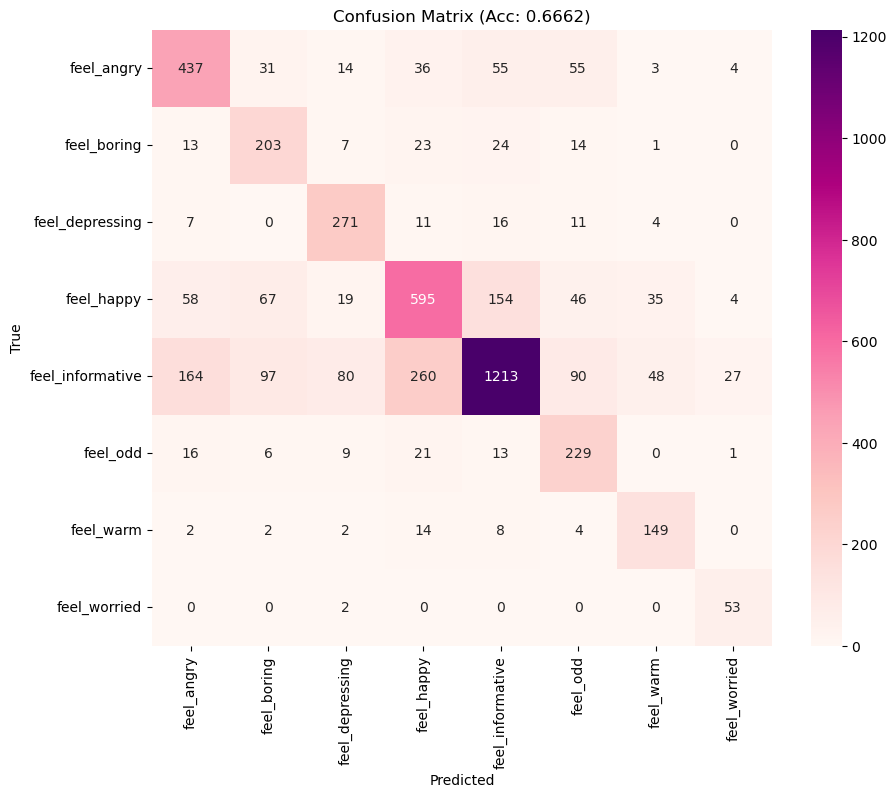


⏱️ 總耗時: 16.2 分鐘


In [1]:
# step2_train_hybrid.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import torch
import gc
import warnings
from scipy.sparse import hstack, csr_matrix
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, f1_score
from sklearn.preprocessing import LabelEncoder, LabelBinarizer, MinMaxScaler
from imblearn.over_sampling import SMOTE 

warnings.filterwarnings('ignore')

# --- 1. BERT 特徵提取 (MPS加速) ---
def get_bert_embeddings(text_list, batch_size=32):
    print("🤖 載入 BERT 模型 (bert-base-chinese)...")
    try:
        tokenizer = BertTokenizer.from_pretrained('bert-base-chinese')
        model = BertModel.from_pretrained('bert-base-chinese')
    except:
        print("❌ 模型下載失敗，請檢查網路。")
        return None

    # M4 Pro 使用 MPS 加速
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    print(f"   -> 硬體加速: {device}")
    model.to(device)
    model.eval()
    
    embeddings = []
    total = len(text_list)
    print(f"🔄 提取 BERT 向量 (共 {total} 筆)...")
    
    for i in range(0, total, batch_size):
        batch_texts = text_list[i : i+batch_size]
        try:
            inputs = tokenizer(list(batch_texts), return_tensors="pt", padding=True, truncation=True, max_length=128)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            with torch.no_grad():
                outputs = model(**inputs)
                batch_embeds = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                embeddings.append(batch_embeds)
        except Exception as e:
            print(f"Batch {i} error: {e}")
        
        if (i // batch_size) % 100 == 0:
            print(f"   -> 進度: {i}/{total}", end='\r')
            
    # 清理顯存
    del model, inputs, tokenizer
    if torch.backends.mps.is_available(): torch.mps.empty_cache()
    gc.collect()
            
    return np.vstack(embeddings).astype(np.float32)

# --- 2. 情緒字典特徵 ---
def get_emotion_features(text_list):
    angry_words = ['怒', '氣', '扯', '罵', '批', '轟', '嗆', '惡劣', '痛心', '離譜', '不滿', '抗議']
    worried_words = ['恐', '憂', '怕', '驚', '擔心', '疑', '不確定', '衝擊', '嚴峻', '焦慮', '變數', '危險']
    depressing_words = ['慘', '死', '傷', '哭', '淚', '哀', '逝', '痛', '遺憾', '悲劇', '心碎', '不幸']
    happy_words = ['喜', '樂', '爽', '讚', '贏', '奪冠', '優惠', '好康', '笑', '棒', '恭喜', '慶祝', '快樂']
    
    features = np.zeros((len(text_list), 4), dtype=np.float32)
    for i, text in enumerate(text_list):
        if pd.isna(text): continue
        t = str(text)
        features[i, 0] = sum(t.count(w) for w in angry_words)
        features[i, 1] = sum(t.count(w) for w in worried_words)
        features[i, 2] = sum(t.count(w) for w in depressing_words)
        features[i, 3] = sum(t.count(w) for w in happy_words)
    return features

if __name__ == '__main__':
    start_time = time.time()
    print("🚀 [步驟二] 混合特徵訓練 (BERT + TF-IDF + SMOTE)")

    # --- A. 讀取資料 (同步讀取斷詞檔與原始檔) ---
    try:
        df_proc = pd.read_csv('Processed_Data.csv') # 斷詞後的
        df_proc['text_segmented'] = df_proc['text_segmented'].fillna('')
        
        df_train = pd.read_csv('TrainingData.csv')
        df_test = pd.read_csv('TestingData.csv')
        df_raw = pd.concat([df_train, df_test], axis=0, ignore_index=True)
        df_raw['raw_text'] = df_raw['Column2'].fillna('') + " " + df_raw['Column3'].fillna('')
        
        print(f"✅ 資料載入完成: {len(df_proc)} 筆")
    except:
        print("❌ 找不到資料檔，請先執行步驟一。")
        exit()

    X_monpa = df_proc['text_segmented'].values
    X_raw = df_raw['raw_text'].tolist() # 轉 list 加速處理
    y = df_proc['Column1'].values
    
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    class_names = le.classes_

    del df_proc, df_train, df_test, df_raw
    gc.collect()

    # --- B. 特徵提取 ---
    # 1. BERT (語意)
    X_bert = get_bert_embeddings(X_raw)
    
    # 2. TF-IDF (關鍵字)
    print("\n🔄 提取 TF-IDF 特徵...")
    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=3, sublinear_tf=True, dtype=np.float32)
    X_tfidf = vectorizer.fit_transform(X_monpa)
    
    # 3. Emotion Dict (情緒強度)
    print("📖 計算情緒字典特徵...")
    X_emo = get_emotion_features(X_raw)
    scaler = MinMaxScaler()
    X_emo = scaler.fit_transform(X_emo)
    
    # 4. 合併
    print("🔗 合併所有特徵...")
    X_combined = hstack([csr_matrix(X_bert), X_tfidf, csr_matrix(X_emo)])
    print(f"   -> 最終特徵維度: {X_combined.shape}")

    del X_bert, X_tfidf, X_emo, X_monpa, X_raw
    gc.collect()

    # --- C. 切分與平衡 ---
    print("✂️ 10-Fold 切分 & SMOTE 平衡...")
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    train_idx, test_idx = next(kf.split(X_combined))
    
    X_train = X_combined.tocsr()[train_idx]
    X_test = X_combined.tocsr()[test_idx]
    y_train = y_encoded[train_idx]
    y_test = y_encoded[test_idx]

    # SMOTE: 關鍵步驟，解決不平衡，提升 Recall
    print("⚖️ 執行 SMOTE 過取樣 (生成新樣本)...")
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print(f"   -> 訓練集擴增: {X_train.shape[0]} -> {X_train_res.shape[0]}")

    # --- D. 訓練 (Voting) ---
    print("🏋️ 訓練模型 (Logistic Regression + SGD)...")
    # 使用 LR 和 SGD 這種適合高維度的線性模型，速度快且準
    clf_lr = LogisticRegression(max_iter=1000, n_jobs=-1, C=1.0)
    clf_sgd = SGDClassifier(loss='modified_huber', penalty='l2', alpha=1e-4, max_iter=2000, n_jobs=-1, random_state=42)
    
    eclf = VotingClassifier(
        estimators=[('lr', clf_lr), ('sgd', clf_sgd)],
        voting='soft',
        n_jobs=1 # 序列執行以防記憶體溢出
    )
    
    eclf.fit(X_train_res, y_train_res)
    print(f"✅ 訓練完成！")

    # --- E. 評估 ---
    print("📊 產生評估報告...")
    y_pred = eclf.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"\n🏆 Accuracy: {acc:.4f}")
    print(f"🏆 F1-Score: {f1:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    # 繪圖
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix (Acc: {acc:.4f})')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()
    
    print(f"\n⏱️ 總耗時: {(time.time() - start_time)/60:.1f} 分鐘")